Importing libraries

In [18]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

import joblib

Loading processed data

In [19]:
X_train = pd.read_csv("../data/processed/X_train_processed.csv")
X_test = pd.read_csv("../data/processed/X_test_processed.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

#.values.ravel() converts (175341,1) to (175341,)

In [20]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(175341, 194)
(175341,)
(82332, 194)
(82332,)


### Model 1 - Logistic Regression

Training the Model

In [21]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train,y_train)

y_pred = log_model.predict(X_test)

Evaluating baseline

In [22]:
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.8095394257396881
              precision    recall  f1-score   support

           0       0.95      0.61      0.74     37000
           1       0.75      0.97      0.85     45332

    accuracy                           0.81     82332
   macro avg       0.85      0.79      0.80     82332
weighted avg       0.84      0.81      0.80     82332



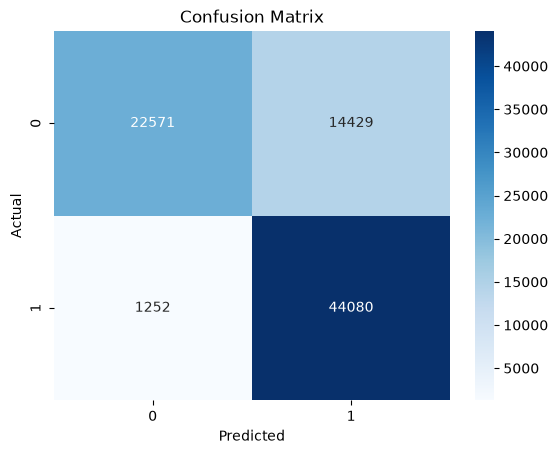

In [23]:
cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Model 2 - Decision Tree

Training the Model

In [24]:
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train,y_train)
tree_pred = tree_model.predict(X_test)

Evaluating baseline

In [25]:
print(accuracy_score(y_test,tree_pred))
print(classification_report(y_test,tree_pred))

0.8635524461934606
              precision    recall  f1-score   support

           0       0.93      0.75      0.83     37000
           1       0.82      0.96      0.89     45332

    accuracy                           0.86     82332
   macro avg       0.88      0.85      0.86     82332
weighted avg       0.87      0.86      0.86     82332



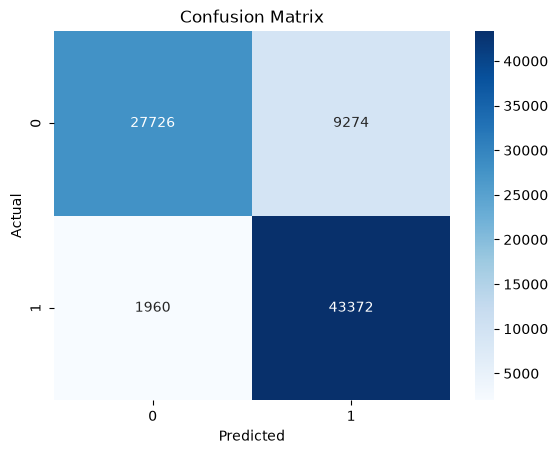

In [26]:
cm = confusion_matrix(y_test,tree_pred)

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Model 3 - Random Forest

Training the Model

In [27]:
rf_model = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)
rf_model.fit(X_train,y_train)
rf_pred = rf_model.predict(X_test)

Evaluating baseline

In [28]:
print(accuracy_score(y_test,rf_pred))
print(classification_report(y_test,rf_pred))

0.8705120730700092
              precision    recall  f1-score   support

           0       0.98      0.73      0.84     37000
           1       0.82      0.98      0.89     45332

    accuracy                           0.87     82332
   macro avg       0.90      0.86      0.86     82332
weighted avg       0.89      0.87      0.87     82332



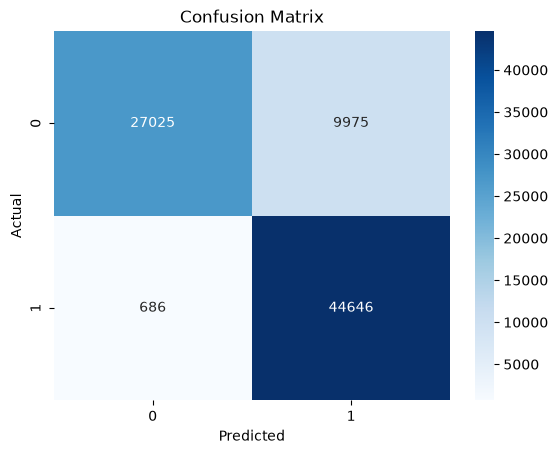

In [29]:
cm = confusion_matrix(y_test,rf_pred)

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Model Comparison Table

In [30]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        0.8095,
        0.8635,
        0.8705
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.8095
1,Decision Tree,0.8635
2,Random Forest,0.8705


Saving the trained models

In [31]:
joblib.dump(log_model,"../models/logistic_regression_model.pkl")
joblib.dump(tree_model,"../models/decision_tree_model.pkl")
joblib.dump(rf_model,"../models/random_forest_model.pkl")

['../models/random_forest_model.pkl']